In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# ============================================================================
# 1. DATA LOADING FUNCTIONS
# ============================================================================

def load_single_slice(file_path):
    """Load a single MPD slice file"""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

def get_slice_files(data_dir):
    """Get all MPD slice file paths as strings"""
    data_path = Path(data_dir)
    slice_files = list(data_path.glob("mpd.slice.*.json"))
    print("**", slice_files)  # Will now print Paths
    return sorted(slice_files) 

def sample_playlists(data_dir, n_files=5):
    """Load a sample of playlists from the first n files for exploration"""
    slice_files = get_slice_files(data_dir)
    
    all_playlists = []
    files_processed = 0

    print(f" Loading sample from first {n_files} files...")
    
    for file_path in slice_files[:n_files]:
        print(f"Loading: {file_path.name}")  # .name gives the filename
        data = load_single_slice(file_path) 12
        all_playlists.extend(data['playlists'])
        files_processed += 1
        
    print(f" Loaded {len(all_playlists)} playlists from {files_processed} files")
    return all_playlists

In [21]:
from pathlib import Path

DATA_DIR = "../data/raw"
files = [str(file) for file in Path(DATA_DIR).glob("mpd.slice.*.json")]
print(files)


['..\\data\\raw\\mpd.slice.0-999.json', '..\\data\\raw\\mpd.slice.1000-1999.json', '..\\data\\raw\\mpd.slice.10000-10999.json', '..\\data\\raw\\mpd.slice.100000-100999.json', '..\\data\\raw\\mpd.slice.101000-101999.json', '..\\data\\raw\\mpd.slice.102000-102999.json', '..\\data\\raw\\mpd.slice.103000-103999.json', '..\\data\\raw\\mpd.slice.104000-104999.json', '..\\data\\raw\\mpd.slice.105000-105999.json', '..\\data\\raw\\mpd.slice.106000-106999.json', '..\\data\\raw\\mpd.slice.107000-107999.json', '..\\data\\raw\\mpd.slice.108000-108999.json', '..\\data\\raw\\mpd.slice.109000-109999.json', '..\\data\\raw\\mpd.slice.11000-11999.json', '..\\data\\raw\\mpd.slice.110000-110999.json', '..\\data\\raw\\mpd.slice.111000-111999.json', '..\\data\\raw\\mpd.slice.112000-112999.json', '..\\data\\raw\\mpd.slice.113000-113999.json', '..\\data\\raw\\mpd.slice.114000-114999.json', '..\\data\\raw\\mpd.slice.115000-115999.json', '..\\data\\raw\\mpd.slice.116000-116999.json', '..\\data\\raw\\mpd.slice.11

In [ ]:
# Load sample data (adjust path to your data directory)
DATA_DIR = "../data/raw"  # Update this to your actual data path
sample_playlists = sample_playlists(DATA_DIR, n_files=3)

print(f"\n Basic Dataset Statistics")
print(f"Number of playlists in sample: {len(sample_playlists)}")

# Examine first playlist structure
first_playlist = sample_playlists[0]
print("sample playlist", first_playlist)
print(f"\n🎭 Sample Playlist Structure:")
print(f"Playlist ID: {first_playlist['pid']}")
print(f"Name: '{first_playlist['name']}'")
print(f"Number of tracks: {first_playlist['num_tracks']}")
print(f"Number of artists: {first_playlist['num_artists']}")
print(f"Number of albums: {first_playlist['num_albums']}")
print(f"Followers: {first_playlist['num_followers']}")

print(f"\n🎵 Sample tracks from '{first_playlist['name']}':")
for i, track in enumerate(first_playlist['tracks'][:5]):
    print(f"  {i+1}. {track['track_name']} - {track['artist_name']}")

** [WindowsPath('../data/raw/mpd.slice.0-999.json'), WindowsPath('../data/raw/mpd.slice.1000-1999.json'), WindowsPath('../data/raw/mpd.slice.10000-10999.json'), WindowsPath('../data/raw/mpd.slice.100000-100999.json'), WindowsPath('../data/raw/mpd.slice.101000-101999.json'), WindowsPath('../data/raw/mpd.slice.102000-102999.json'), WindowsPath('../data/raw/mpd.slice.103000-103999.json'), WindowsPath('../data/raw/mpd.slice.104000-104999.json'), WindowsPath('../data/raw/mpd.slice.105000-105999.json'), WindowsPath('../data/raw/mpd.slice.106000-106999.json'), WindowsPath('../data/raw/mpd.slice.107000-107999.json'), WindowsPath('../data/raw/mpd.slice.108000-108999.json'), WindowsPath('../data/raw/mpd.slice.109000-109999.json'), WindowsPath('../data/raw/mpd.slice.11000-11999.json'), WindowsPath('../data/raw/mpd.slice.110000-110999.json'), WindowsPath('../data/raw/mpd.slice.111000-111999.json'), WindowsPath('../data/raw/mpd.slice.112000-112999.json'), WindowsPath('../data/raw/mpd.slice.113000-1

In [23]:
rows = []
for playlist in sample_playlists:
    for track in playlist["tracks"]:
        rows.append({
            "playlist_id": playlist["pid"],
            "playlist_name": playlist["name"],
            "playlist_followers": playlist["num_followers"],
            "playlist_num_tracks": playlist["num_tracks"],
            "playlist_num_artists": playlist["num_artists"],
            "playlist_num_albums": playlist["num_albums"],
            "track_position": track["pos"],
            "track_name": track["track_name"],
            "artist_name": track["artist_name"],
            "track_uri": track["track_uri"],
            "artist_uri": track["artist_uri"],
            "album_name": track["album_name"],
            "album_uri": track["album_uri"],
            "duration_ms": track["duration_ms"],
        })

In [24]:
df = pd.DataFrame(rows)

In [26]:
df.head()

,playlist_id,playlist_name,playlist_followers,playlist_num_tracks,playlist_num_artists,playlist_num_albums,track_position,track_name,artist_name,track_uri,artist_uri,album_name,album_uri,duration_ms
0,0,Throwbacks,1,52,37,47,0,Lose Control (feat. Ciara & Fat Man Scoop),Missy Elliott,spotify:track:0UaMYEvWZi0ZqiDOoHU3YI,spotify:artist:2wIVse2owClT7go1WT98tk,The Cookbook,spotify:album:6vV5UrXcfyQD1wu4Qo2I9K,226863
1,0,Throwbacks,1,52,37,47,1,Toxic,Britney Spears,spotify:track:6I9VzXrHxO9rA9A5euc8Ak,spotify:artist:26dSoYclwsYLMAKD3tpOr4,In The Zone,spotify:album:0z7pVBGOD7HCIB7S8eLkLI,198800
2,0,Throwbacks,1,52,37,47,2,Crazy In Love,Beyoncé,spotify:track:0WqIKmW4BTrj3eJFmnCKMv,spotify:artist:6vWDO969PvNqNYHIOW5v0m,Dangerously In Love (Alben für die Ewigkeit),spotify:album:25hVFAxTlDvXbx2X2QkUkE,235933
3,0,Throwbacks,1,52,37,47,3,Rock Your Body,Justin Timberlake,spotify:track:1AWQoqb9bSvzTjaLralEkT,spotify:artist:31TPClRtHm23RisEBtV3X7,Justified,spotify:album:6QPkyl04rXwTGlGlcYaRoW,267266
4,0,Throwbacks,1,52,37,47,4,It Wasn't Me,Shaggy,spotify:track:1lzr43nnXAijIGYnCT8M8H,spotify:artist:5EvFsr3kj42KNv97ZEnqij,Hot Shot,spotify:album:6NmFmPX56pcLBOFMhIiKvF,227600


In [27]:
df.shape

(200773, 14)

In [29]:
n_playlists = df["playlist_id"].nunique()
n_artists = df["artist_name"].nunique()
n_albums = df["album_name"].nunique()
n_tracks = df["track_name"].nunique()

print(f"Number of unique playlists: {n_playlists}")
print(f"Number of unique artists: {n_artists}")
print(f"Number of unique albums: {n_albums}")
print(f"Number of unique tracks: {n_tracks}")

Number of unique playlists: 3000
Number of unique artists: 18729
Number of unique albums: 34800
Number of unique tracks: 62891


**Track duration analysis**

In [32]:
df["duration_minutes"] = df["duration_ms"] / 60000

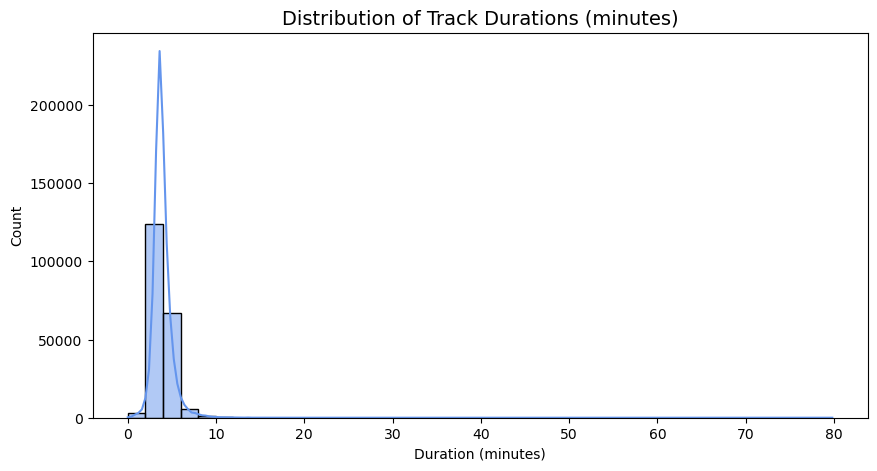

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df["duration_minutes"], kde=True, bins=40, color="cornflowerblue")
plt.title("Distribution of Track Durations (minutes)", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.show()

**Number of tracks per list**

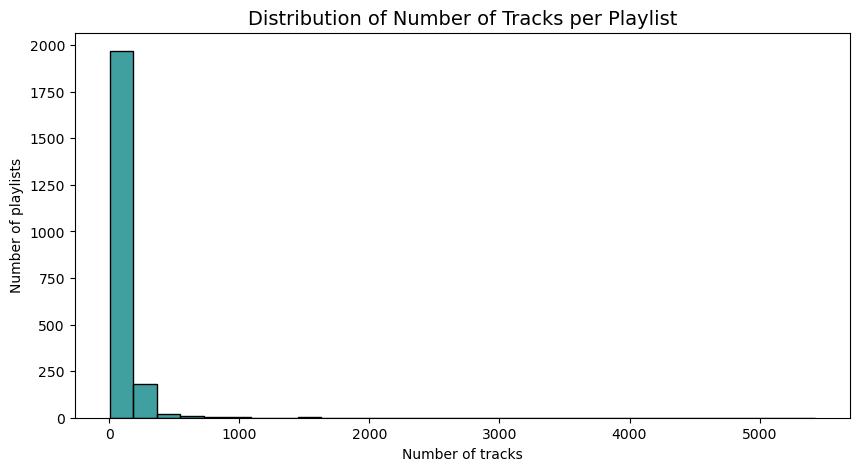

count    2192.000000
mean       91.593522
std       164.086886
min         5.000000
25%        28.000000
50%        55.000000
75%       111.000000
max      5423.000000
Name: track_name, dtype: float64


In [34]:
playlist_sizes = df.groupby("playlist_name")["track_name"].count()

plt.figure(figsize=(10,5))
sns.histplot(playlist_sizes, kde=False, bins=30, color="teal")
plt.title("Distribution of Number of Tracks per Playlist", fontsize=14)
plt.xlabel("Number of tracks")
plt.ylabel("Number of playlists")
plt.show()

# Stats
print(playlist_sizes.describe())


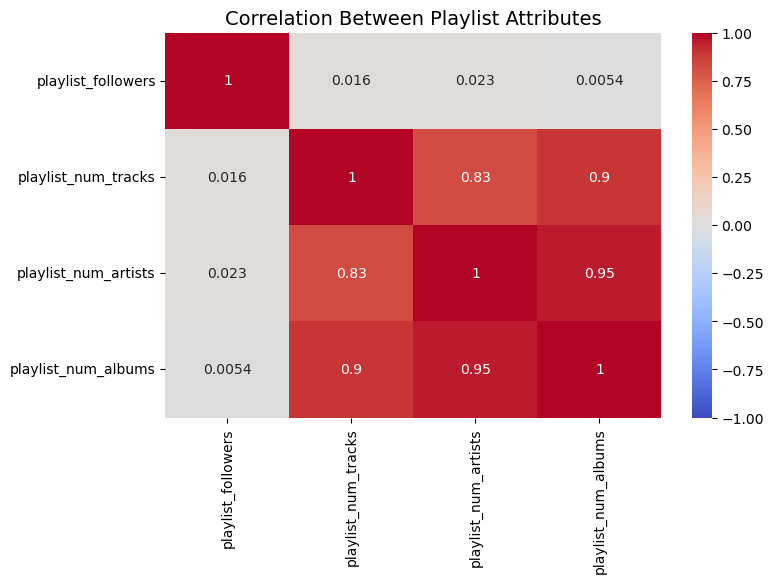

In [35]:
playlist_level = df.groupby("playlist_id")[["playlist_followers", "playlist_num_tracks", "playlist_num_artists", "playlist_num_albums"]].first()

# Correlation Matrix
corr = playlist_level.corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Playlist Attributes", fontsize=14)
plt.show()


In [36]:
from itertools import combinations

playlist_tracks = df.groupby('playlist_id')['track_name'].apply(set)

similarity_records = []
for p1, p2 in combinations(playlist_tracks.index, 2):
    common = len(playlist_tracks[p1].intersection(playlist_tracks[p2]))
    union = len(playlist_tracks[p1].union(playlist_tracks[p2]))
    jaccard_sim = common / union if union > 0 else 0
    similarity_records.append((p1, p2, jaccard_sim))

similarity_df = pd.DataFrame(similarity_records, columns=["playlist_1", "playlist_2", "jaccard_score"])
similarity_df = similarity_df.sort_values(by="jaccard_score", ascending=False)

print("\nTop 5 Most Similar Playlists:\n", similarity_df.head())



Top 5 Most Similar Playlists:
          playlist_1  playlist_2  jaccard_score
764543          266       10321       0.846154
1865089         704        1954       0.730088
319035          108        1030       0.653061
3195776        1385        1967       0.515152
912009          321        1012       0.484848


**Artist Diversity Score for Each Playlist**

artist_diversity = unique_artists / total_tracks

In [37]:
artist_diversity = df.groupby("playlist_name")["artist_name"].nunique() / df.groupby("playlist_name")["track_name"].count()
artist_diversity = artist_diversity.sort_values(ascending=False)

print("\nTop 5 Playlists by Artist Diversity Score:\n", artist_diversity.head())


Top 5 Playlists by Artist Diversity Score:
 playlist_name
Road Trip Mix    1.0
Vinyasa          1.0
Sad Songs        1.0
Shape of You     1.0
Silence          1.0
dtype: float64


**Track Popularity vs. Playlist Follower Count**

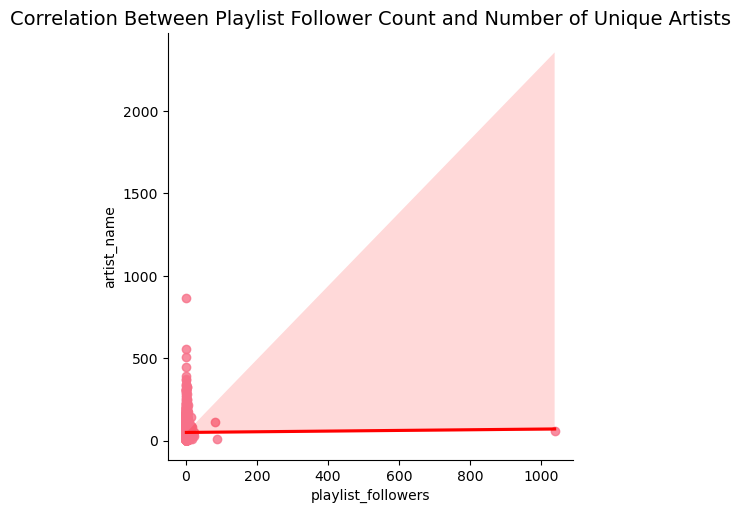

In [38]:
playlist_metrics = df.groupby("playlist_name").agg({
    "duration_minutes": "mean",
    "artist_name": pd.Series.nunique,
    "playlist_followers": "first"
}).reset_index()

sns.lmplot(data=playlist_metrics, x="playlist_followers", y="artist_name", line_kws={'color': 'red'})
plt.title("Correlation Between Playlist Follower Count and Number of Unique Artists", fontsize=14)
plt.show()


In [ ]:
#Find artists that appear across many playlists 
artist_impact = df.groupby("artist_name")["playlist_name"].nunique().sort_values(ascending=False)
print("\nTop 10 Artists by Number of Playlists Featured:\n", artist_impact.head(10))



Top 10 Artists by Number of Playlists Featured:
 artist_name
Drake               508
Rihanna             399
Kanye West          372
The Weeknd          364
Kendrick Lamar      326
Ed Sheeran          309
The Chainsmokers    304
Calvin Harris       300
Maroon 5            298
Beyoncé             282
Name: playlist_name, dtype: int64


**Duration Anomalies and Outliers**

In [40]:
long_tracks = df[df["duration_minutes"] > df["duration_minutes"].quantile(0.99)]
short_tracks = df[df["duration_minutes"] < df["duration_minutes"].quantile(0.01)]

print("\nLongest Tracks:\n", long_tracks[["track_name", "artist_name", "duration_minutes"]].sort_values(by="duration_minutes", ascending=False).head(5))
print("\nShortest Tracks:\n", short_tracks[["track_name", "artist_name", "duration_minutes"]].sort_values(by="duration_minutes", ascending=True).head(5))



Longest Tracks:
                                     track_name       artist_name  \
130551                      9JA Jamz Vol.6 - 6       Best of 9JA   
195354  Bonobo Late Night Tales Continuous Mix  Late Night Tales   
119969  Bonobo Late Night Tales Continuous Mix  Late Night Tales   
156193    Club Life: Miami (Continuous DJ Mix)            Tiësto   
156138                 4x4=12 - Continuous Mix          deadmau5   

        duration_minutes  
130551         79.815633  
195354         74.966567  
119969         74.966567  
156193         74.531400  
156138         69.916667  

Shortest Tracks:
                 track_name        artist_name  duration_minutes
63342                Paris  Tigers in the Sky            0.0000
56565             The Famm       Marty Grimes            0.0000
95999             The Famm       Marty Grimes            0.0000
46663             The Famm       Marty Grimes            0.0000
59093  Oxygen - Radio Edit    Bass Modulators            0.0031
